# `local_thickness_conv`
Computes local thickness by performing the dilation step with FFT-based convolution against a round structuring element instead of a distance transform. Useful when the distance-transform approach is the bottleneck.

See the `local_thickness` notebook for a detailed walk-through of the shared concepts; this page focuses on the variant-specific arguments. The wrapper `ps.filters.local_thickness` dispatches to this function when its `method` argument selects this variant.

In [1]:
import matplotlib.pyplot as plt

import porespy as ps

ps.visualization.set_mpl_style()

The arguments and their defaults are:

In [2]:
import inspect

inspect.signature(ps.filters.local_thickness_conv)

<Signature (im: numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[~_ScalarT]], dt: numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[~_ScalarT]] = None, sizes: int = 25, smooth: bool = True)>

## `im` and `sizes`
`im` is the boolean void mask. `sizes` controls the number or values of radii used; pass an integer for that many logarithmically spaced sizes, or an array of explicit radii.

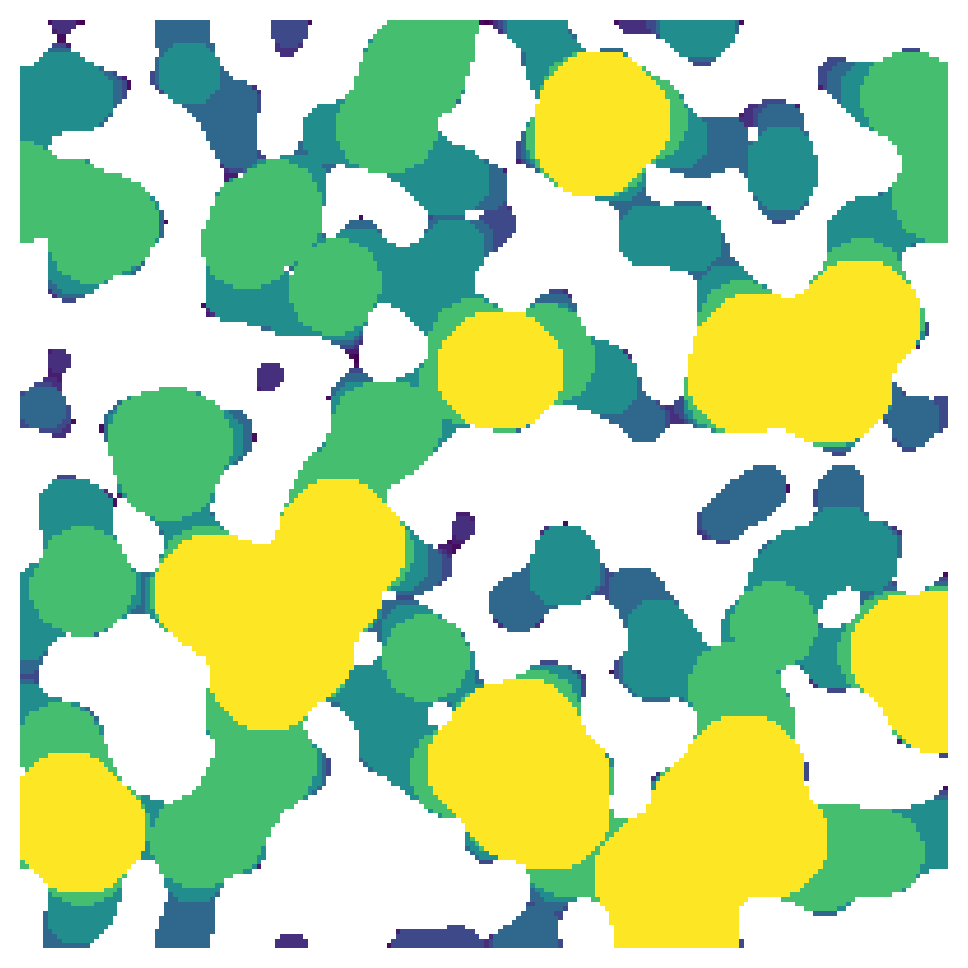

In [3]:
im = ps.generators.blobs(shape=[200, 200], porosity=0.6, seed=0)
lt = ps.filters.local_thickness_conv(im=im, sizes=10)

fig, ax = plt.subplots(figsize=[5, 5])
ax.imshow(lt / im, origin='lower', interpolation='none')
ax.axis(False);

## `dt`
Pre-computed distance transform of the void phase, used during the erosion step. Pass it in to avoid recomputing.

In [4]:
from porespy.tools import get_edt

dt = get_edt()(im)
lt = ps.filters.local_thickness_conv(im=im, dt=dt, sizes=10)

## `smooth`
Trims single-voxel protrusions from the structuring element used during the convolution-based dilation.

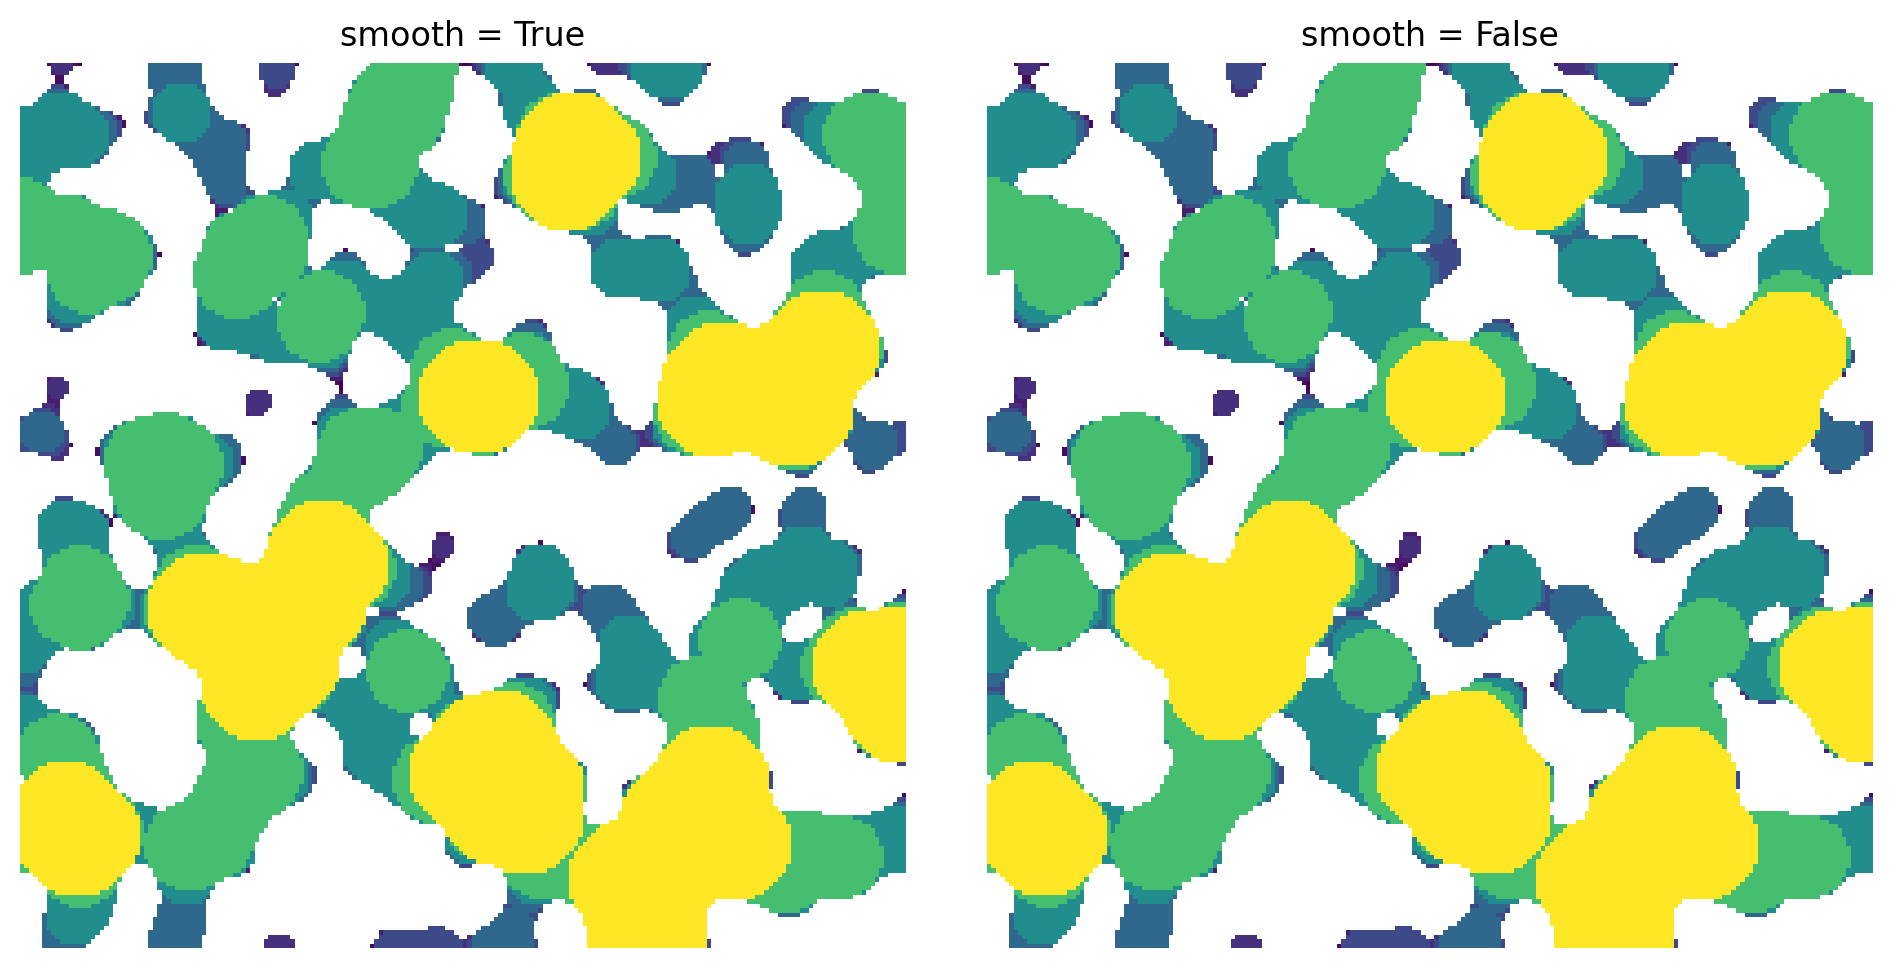

In [5]:
lt_smooth = ps.filters.local_thickness_conv(im=im, sizes=10, smooth=True)
lt_rough = ps.filters.local_thickness_conv(im=im, sizes=10, smooth=False)

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(lt_smooth / im, origin='lower', interpolation='none')
ax[0].set_title('smooth = True')
ax[0].axis(False)
ax[1].imshow(lt_rough / im, origin='lower', interpolation='none')
ax[1].set_title('smooth = False')
ax[1].axis(False);